## SF Vendor Payment Analysis

In [12]:
import pandas as pd
import requests
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## Fetch data from SF Open Data

In [13]:
URL = 'https://data.sfgov.org/resource/n9pm-xkyq.csv?$where=vendor="SAN FRANCISCO SAFE INC"'

resp = requests.get(URL, timeout=60)
resp.raise_for_status()

from io import StringIO
df = pd.read_csv(StringIO(resp.text))

print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
df.head(3)

Rows: 422  |  Columns: 32


,fiscal_year,related_govt_units,organization_group_code,organization_group,department_code,department,program_code,program,character_code,character,...,vouchers_paid,vouchers_pending,vouchers_pending_retainage,voucher,data_as_of,data_loaded_at,non_profit_indicator,contract_number,contract_title,purchasing_authority_title
0,2019,NO,1,Public Protection,POL,POL Police,OPR,Operating,CITY_GR_PROG,City Grant Program,...,84927.2,0.0,0,0062320501,2018-12-03 00:00:00-08:00,2026-06-01T03:06:56.000,X,1.000012e+09,POL - SF SAFE CRIME PREV EDU,AUTHORIZED BY GRANT - NOT PURCHASING AUTHORITY
1,2019,NO,2,"Public Works, Transportation & Commerce",PUC,PUC Public Utilities Commsn,OPR,Operating,NON_PERS_SVCS,Non-Personnel Services,...,500.0,0.0,0,0061947001,2018-11-29 00:00:00-08:00,2026-06-01T03:06:56.000,X,NaN,NaN,PROP Q AUTHORITY NOT BID
2,2019,NO,2,"Public Works, Transportation & Commerce",MTA,MTA Municipal Transprtn Agncy,OPR,Operating,MTL_SUPP,Materials & Supplies,...,2500.0,0.0,0,0067612101,2019-01-30 00:00:00-08:00,2026-06-01T03:06:56.000,X,NaN,NaN,PROP Q AUTHORITY NOT BID


## Load into DuckDB

In [14]:
con = duckdb.connect()  # in-memory database

con.execute("CREATE TABLE payments AS SELECT * FROM df")

con.execute("SELECT COUNT(*) AS total_rows FROM payments").df()

,total_rows
0,422


## Explore — schema & sample queries

In [15]:
con.execute("DESCRIBE payments").df()

,column_name,column_type,null,key,default,extra
0,fiscal_year,BIGINT,YES,None,None,None
1,related_govt_units,VARCHAR,YES,None,None,None
2,organization_group_code,BIGINT,YES,None,None,None
3,organization_group,VARCHAR,YES,None,None,None
4,department_code,VARCHAR,YES,None,None,None
5,department,VARCHAR,YES,None,None,None
6,program_code,VARCHAR,YES,None,None,None
7,program,VARCHAR,YES,None,None,None
8,character_code,VARCHAR,YES,None,None,None
9,character,VARCHAR,YES,None,None,None


In [16]:
con.execute("""
    SELECT
        fiscal_year,
        department,
        program,
        ROUND(SUM(vouchers_paid), 2)    AS total_paid,
        ROUND(SUM(vouchers_pending), 2) AS total_pending
    FROM payments
    GROUP BY fiscal_year, department, program
    ORDER BY fiscal_year, total_paid DESC
""").df()

,fiscal_year,department,program,total_paid,total_pending
0,2007,POL Police,Operations And Administration,585374.10,14604.9
1,2007,MYR Mayor,Criminal Justice,9600.00,0.0
2,2007,HRD Human Resources,Administration,900.00,0.0
3,2007,MTA Municipal Transprtn Agncy,Administration,600.00,0.0
4,2008,POL Police,Operations And Administration,566319.00,80558.2
...,...,...,...,...,...
57,2023,POL Police,Operating,1440602.96,0.0
58,2023,ECN Economic & Wrkfrce Dvlpmnt,Operating,1400000.00,0.0
59,2023,DPW Public Works,Operating,2230.00,0.0
60,2024,ECN Economic & Wrkfrce Dvlpmnt,Operating,962537.77,0.0


## Chart — total vouchers paid per fiscal year

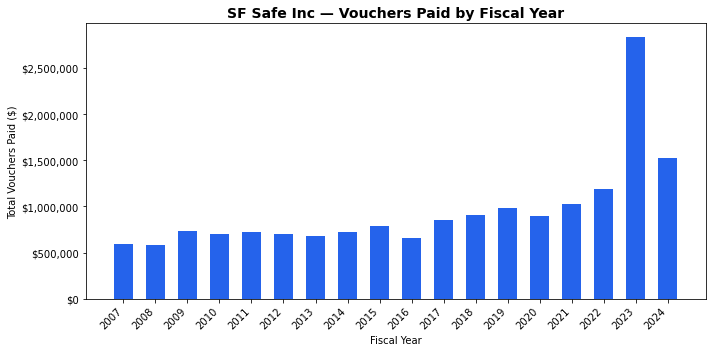

In [17]:
annual = con.execute("""
    SELECT
        fiscal_year,
        SUM(vouchers_paid) AS total_paid
    FROM payments
    GROUP BY fiscal_year
    ORDER BY fiscal_year
""").df()

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(annual["fiscal_year"].astype(str), annual["total_paid"], color="#2563eb", width=0.6)

ax.set_title("SF Safe Inc — Vouchers Paid by Fiscal Year", fontsize=14, fontweight="bold")
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("Total Vouchers Paid ($)")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
## Citywide Nonprofit Spending (`qkex-vh98`)

In [18]:
url_nonprofit = 'https://data.sfgov.org/resource/qkex-vh98.csv?$where=supplier_name=%22San%20Francisco%20Safe%20Inc%22'

resp_np = requests.get(url_nonprofit, timeout=60)
resp_np.raise_for_status()
df_nonprofit = pd.read_csv(StringIO(resp_np.text))

print(f"Rows: {len(df_nonprofit):,}  |  Columns: {df_nonprofit.shape[1]}")
df_nonprofit.head(3)

Rows: 13  |  Columns: 15


,fiscal_year,supplier_name,product_code,contract_number,contract_title,nonprofit,remaining_balance,type_of_goods_and_services,sole_source,completed_payments,date,department_code,department,data_as_of,data_loaded
0,2022,San Francisco Safe Inc,95200 HUMAN SERVICES,1.000012e+09,POL - SF SAFE CRIME PREV EDU,CON-marked Nonprofit,0.0,Community Based Org Srvcs,NaN,9688.0,"Saturday, January 1, 2022",MYR,Mayor's Office of Housing and Community Develo...,2025-10-02T00:00:00.000,2025-10-30T00:00:00.000
1,2021,San Francisco Safe Inc,95200 HUMAN SERVICES,1.000012e+09,POL - SF SAFE CRIME PREV EDU,CON-marked Nonprofit,0.0,Community Based Org Srvcs,NaN,1023755.0,"Friday, January 1, 2021",POL,Police,2025-10-02T00:00:00.000,2025-10-30T00:00:00.000
2,2020,San Francisco Safe Inc,95200 HUMAN SERVICES,1.000012e+09,POL - SF SAFE CRIME PREV EDU,CON-marked Nonprofit,0.0,Community Based Org Srvcs,NaN,707395.0,"Wednesday, January 1, 2020",POL,Police,2025-10-02T00:00:00.000,2025-10-30T00:00:00.000


In [19]:
con.execute("CREATE OR REPLACE TABLE nonprofit_spending AS SELECT * FROM df_nonprofit")
con.execute("SELECT COUNT(*) AS total_rows FROM nonprofit_spending").df()

,total_rows
0,13


---
## Supplier Contracts (`cqi5-hm2d`)

In [20]:
url_contracts = 'https://data.sfgov.org/resource/cqi5-hm2d.csv?$where=prime_contractor=%22SAN%20FRANCISCO%20SAFE%20INC%22'

resp_ct = requests.get(url_contracts, timeout=60)
resp_ct.raise_for_status()
df_contracts = pd.read_csv(StringIO(resp_ct.text))

print(f"Rows: {len(df_contracts):,}  |  Columns: {df_contracts.shape[1]}")
df_contracts.head(3)

Rows: 5  |  Columns: 21


,contract_no,contract_title,term_start_date,term_end_date,contract_type,purchasing_authority,sole_source_flg,department_code,department,prime_contractor,...,project_team_lbe_status,non_profit,project_team_constituent,scope_of_work,agreed_amt,consumed_amt,pmt_amt,remaining_amt,data_as_of,data_loaded_at
0,1000005263,T0 INCREASE INDIVIDUAL & COMM.,1998-11-12T00:00:00.000,2022-06-30T00:00:00.000,Purchasing Contract,No purchasing authority in legacy system,NaN,MYR,MYR Mayor,SAN FRANCISCO SAFE INC,...,LBE,X,Prime Contractor,T0 INCREASE INDIVIDUAL & COMM.,391421.72,0.00,0.00,391421.72,2026-05-18T10:42:13.000,2026-06-01T02:59:16.666
1,1000012054,POL - SF SAFE CRIME PREV EDU,2018-07-01T00:00:00.000,2023-06-30T00:00:00.000,"Grant Contracts (City as Grantor, previously n...",AUTHORIZED BY GRANT - NOT PURCHASING AUTHORITY,NaN,POL,POL Police,SAN FRANCISCO SAFE INC,...,Non-LBE,X,Prime Contractor,POL - SF SAFE CRIME PREV EDU,5433774.00,0.01,4490563.79,943210.20,2026-05-18T10:42:13.000,2026-06-01T02:59:16.666
2,1000020695,ECN Commercial Corridor Camera,2021-01-01T00:00:00.000,2023-06-30T00:00:00.000,"Grant Contracts (City as Grantor, previously n...",GRANTS ONLY - COMPETITIVE BID,NaN,ECN,ECN Economic & Wrkfrce Dvlpmnt,SAN FRANCISCO SAFE INC,...,LBE,X,Prime Contractor,ECN Commercial Corridor Camera,1060000.00,0.00,1000000.00,60000.00,2026-05-18T10:42:13.000,2026-06-01T02:59:16.666


In [21]:
con.execute("CREATE OR REPLACE TABLE supplier_contracts AS SELECT * FROM df_contracts")
con.execute("SELECT COUNT(*) AS total_rows FROM supplier_contracts").df()

,total_rows
0,5


---
## Vendor Payments — Purchase Order Summary (`p5r5-fd7g`)

In [22]:
url_po = 'https://data.sfgov.org/resource/p5r5-fd7g.csv?$where=vendor=%22SAN%20FRANCISCO%20SAFE%20INC%22'

resp_po = requests.get(url_po, timeout=60)
resp_po.raise_for_status()
df_po = pd.read_csv(StringIO(resp_po.text))

print(f"Rows: {len(df_po):,}  |  Columns: {df_po.shape[1]}")
df_po.head(3)

Rows: 158  |  Columns: 33


,fiscal_year,related_govt_units,organization_group_code,organization_group,department_code,department,program_code,program,character_code,character,...,vouchers_pending,encumbrance_balance,vouchers_pending_retainage,data_as_of,data_loaded_at,non_profit_indicator,contract_number,contract_title,purchase_order_date,purchasing_authority_description
0,2022,NO,1,Public Protection,POL,POL Police,OPR,Operating,CITY_GR_PROG,City Grant Program,...,0.0,0.0,0.0,2021-08-19T16:59:08.000,2026-06-01T02:46:49.000,X,1.000012e+09,POL - SF SAFE CRIME PREV EDU,2021-08-11T00:00:00.000,AUTHORIZED BY GRANT - NOT PURCHASING AUTHORITY
1,2023,NO,1,Public Protection,POL,POL Police,OPR,Operating,CITY_GR_PROG,City Grant Program,...,0.0,0.0,0.0,2023-06-06T14:02:21.000,2026-06-01T02:46:49.000,X,1.000012e+09,POL - SF SAFE CRIME PREV EDU,2023-06-06T00:00:00.000,AUTHORIZED BY GRANT - NOT PURCHASING AUTHORITY
2,2023,NO,1,Public Protection,POL,POL Police,OPR,Operating,CITY_GR_PROG,City Grant Program,...,0.0,0.0,0.0,2025-06-13T10:26:33.000,2026-06-01T02:46:49.000,X,1.000012e+09,POL - SF SAFE CRIME PREV EDU,2022-11-08T00:00:00.000,AUTHORIZED BY GRANT - NOT PURCHASING AUTHORITY


In [23]:
con.execute("CREATE OR REPLACE TABLE vendor_payments_po AS SELECT * FROM df_po")
con.execute("SELECT COUNT(*) AS total_rows FROM vendor_payments_po").df()

,total_rows
0,158


---
# Data Model & Fraud Signal Analysis

## Data Model

```
supplier_contracts (5 rows)
  contract_no  ◄──────────────────────────────────────────────────────┐
  agreed_amt                                                           │
  term_start_date / term_end_date                                      │  CAST(contract_number AS BIGINT)
  scope_of_work                                                        │
                                                                       │
payments (422 rows) ─────────────────── contract_number (NULL: 71%) ──┤
  fiscal_year / vouchers_paid / vouchers_pending                       │
  purchase_order / department / program                                │
                                                                       │
nonprofit_spending (13 rows) ──────────── contract_number ────────────┤
  fiscal_year / completed_payments / remaining_balance                 │
                                                                       │
vendor_payments_po (158 rows) ──────── contract_number (NULL: 69%) ───┘
  fiscal_year / vouchers_paid / encumbrance_balance / purchase_order_date
```

**⚠ 71% of payment vouchers carry no contract number — money paid without a contractual reference.**

In [ ]:
# Join coverage: how many payment rows actually resolve to a formal contract
coverage = con.execute("""
    SELECT
        COUNT(*)                                              AS total_payment_rows,
        COUNT(contract_number)                                AS has_contract_number,
        COUNT(*)   - COUNT(contract_number)                  AS missing_contract_number,
        ROUND((COUNT(*) - COUNT(contract_number)) * 100.0
              / COUNT(*), 1)                                 AS pct_orphaned,
        COUNT(DISTINCT CAST(contract_number AS BIGINT))      AS unique_contract_refs,
        (SELECT COUNT(*) FROM supplier_contracts)            AS formal_contracts_on_file
    FROM payments
""").df()
coverage

In [ ]:
# Master contract view: contract metadata joined to payment & nonprofit totals
con.execute("""
CREATE OR REPLACE VIEW contract_master AS
SELECT
    sc.contract_no,
    sc.contract_title,
    sc.department                                                      AS contract_dept,
    sc.scope_of_work,
    sc.agreed_amt,
    sc.pmt_amt                                                         AS system_pmt_amt,
    sc.remaining_amt,
    strptime(sc.term_start_date, '%Y-%m-%dT%H:%M:%S.%f')             AS term_start,
    strptime(sc.term_end_date,   '%Y-%m-%dT%H:%M:%S.%f')             AS term_end,
    COALESCE(SUM(p.vouchers_paid),  0)                                AS vouchers_paid_total,
    COALESCE(SUM(p.vouchers_pending), 0)                              AS vouchers_pending_total,
    COUNT(DISTINCT p.fiscal_year)                                     AS payment_years,
    COALESCE(SUM(ns.completed_payments), 0)                           AS nonprofit_reported_total
FROM supplier_contracts sc
LEFT JOIN payments p
       ON CAST(p.contract_number AS BIGINT) = sc.contract_no
LEFT JOIN nonprofit_spending ns
       ON CAST(ns.contract_number AS BIGINT) = sc.contract_no
GROUP BY 1,2,3,4,5,6,7,8,9
""")

con.execute("SELECT * FROM contract_master ORDER BY agreed_amt DESC").df()

---
## Signal 1 — Payments Without Contracts (Orphan Vouchers)
Vouchers paid with no `contract_number` cannot be traced to any agreed scope of work or spending limit.
A high and growing orphan rate means money was disbursed outside the normal procurement control.

In [ ]:
orphan = con.execute("""
    SELECT
        fiscal_year,
        SUM(CASE WHEN contract_number IS NULL THEN vouchers_paid ELSE 0 END) AS orphan_paid,
        SUM(CASE WHEN contract_number IS NOT NULL THEN vouchers_paid ELSE 0 END) AS contracted_paid,
        COUNT(CASE WHEN contract_number IS NULL THEN 1 END) AS orphan_vouchers,
        COUNT(CASE WHEN contract_number IS NOT NULL THEN 1 END) AS contracted_vouchers
    FROM payments
    GROUP BY fiscal_year
    ORDER BY fiscal_year
""").df()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# $ amounts
axes[0].bar(orphan["fiscal_year"].astype(str), orphan["orphan_paid"],
            color="#dc2626", label="No contract")
axes[0].bar(orphan["fiscal_year"].astype(str), orphan["contracted_paid"],
            bottom=orphan["orphan_paid"], color="#2563eb", label="Has contract")
axes[0].set_title("Signal 1 — Vouchers Paid: Contracted vs Orphan ($)", fontweight="bold")
axes[0].set_ylabel("Amount ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# voucher counts
axes[1].bar(orphan["fiscal_year"].astype(str), orphan["orphan_vouchers"],
            color="#dc2626", label="No contract")
axes[1].bar(orphan["fiscal_year"].astype(str), orphan["contracted_vouchers"],
            bottom=orphan["orphan_vouchers"], color="#2563eb", label="Has contract")
axes[1].set_title("Signal 1 — Voucher Count: Contracted vs Orphan", fontweight="bold")
axes[1].set_ylabel("Number of Vouchers")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()
orphan

---
## Signal 2 — Overbilling: Payments vs Contracted Amount
Compare what was formally agreed (`agreed_amt`) to what was actually paid.
Payments exceeding the contracted ceiling — especially without an amendment — are a core fraud indicator.

In [ ]:
overbill = con.execute("""
    SELECT
        contract_no,
        contract_title,
        agreed_amt,
        vouchers_paid_total,
        system_pmt_amt,
        ROUND(vouchers_paid_total - agreed_amt, 2)            AS overbill_amount,
        ROUND((vouchers_paid_total / agreed_amt - 1) * 100, 1) AS overbill_pct,
        term_start::DATE AS start_date,
        term_end::DATE   AS end_date,
        payment_years
    FROM contract_master
    WHERE agreed_amt > 0
    ORDER BY overbill_pct DESC
""").df()

# Chart
fig, ax = plt.subplots(figsize=(11, 4))
labels = [f"#{r.contract_no}\n{r.contract_title[:30]}" for _, r in overbill.iterrows()]
x = range(len(overbill))
w = 0.35
ax.bar([i - w/2 for i in x], overbill["agreed_amt"], width=w, label="Agreed amount", color="#2563eb")
ax.bar([i + w/2 for i in x], overbill["vouchers_paid_total"], width=w, label="Actual paid", color="#dc2626")
ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=8)
ax.set_title("Signal 2 — Agreed Amount vs Actual Vouchers Paid per Contract", fontweight="bold")
ax.set_ylabel("Amount ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

overbill[["contract_no","contract_title","agreed_amt","vouchers_paid_total","overbill_amount","overbill_pct","start_date","end_date"]]

---
## Signal 3 — Year-over-Year Payment Trajectory
Sudden step-changes in annual payments — especially outpacing any contract amendments — 
can indicate inflated billing. Also shows trajectory relative to formal contract periods.

In [ ]:
yoy = con.execute("""
    WITH annual AS (
        SELECT fiscal_year, SUM(vouchers_paid) AS total_paid
        FROM payments
        GROUP BY fiscal_year
    )
    SELECT
        fiscal_year,
        total_paid,
        LAG(total_paid) OVER (ORDER BY fiscal_year)  AS prev_year_paid,
        ROUND(
            (total_paid / NULLIF(LAG(total_paid) OVER (ORDER BY fiscal_year), 0) - 1) * 100
        , 1) AS yoy_growth_pct
    FROM annual
    ORDER BY fiscal_year
""").df()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

years = yoy["fiscal_year"].astype(str)
ax1.bar(years, yoy["total_paid"], color="#2563eb", alpha=0.7, label="Total paid ($)")
ax2.plot(years, yoy["yoy_growth_pct"], color="#dc2626", marker="o", linewidth=2, label="YoY growth %")
ax2.axhline(0, color="gray", linewidth=0.8, linestyle="--")

ax1.set_ylabel("Total Paid ($)")
ax2.set_ylabel("YoY Growth (%)")
ax1.set_title("Signal 3 — Annual Payments & Year-over-Year Growth", fontweight="bold")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax1.tick_params(axis='x', rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

yoy

---
## Signal 4 — Payments After Contract End Date
Vouchers dated after a contract's `term_end_date` suggest the city kept paying after the agreement expired —
a common mechanism for extending fraud without a renewal paper trail.

In [ ]:
post_contract = con.execute("""
    SELECT
        p.fiscal_year,
        p.contract_number::BIGINT                                     AS contract_no,
        sc.contract_title,
        sc.term_end_date::DATE                                         AS contract_ended,
        YEAR(strptime(sc.term_end_date, '%Y-%m-%dT%H:%M:%S.%f'))     AS contract_end_year,
        ROUND(SUM(p.vouchers_paid), 2)                                AS paid_after_end,
        COUNT(*)                                                       AS voucher_count
    FROM payments p
    JOIN supplier_contracts sc
      ON p.contract_number::BIGINT = sc.contract_no
    WHERE p.fiscal_year > YEAR(strptime(sc.term_end_date, '%Y-%m-%dT%H:%M:%S.%f'))
      AND p.vouchers_paid > 0
    GROUP BY 1,2,3,4,5
    ORDER BY paid_after_end DESC
""").df()

print(f"Payments found AFTER contract end date: {len(post_contract)} contract-year combos")
print(f"Total $ paid after contract expiry: ${post_contract['paid_after_end'].sum():,.2f}")
post_contract

---
## Signal 5 — Cross-Dataset Discrepancy: Nonprofit Spending vs Payment Records
The `nonprofit_spending` dataset is the city's own reporting of payments to nonprofits.
If `completed_payments` there doesn't reconcile with the voucher records in `payments`,
someone may be reporting different numbers to different oversight bodies.

In [ ]:
discrepancy = con.execute("""
    WITH voucher_by_year AS (
        SELECT fiscal_year, SUM(vouchers_paid) AS vouchers_paid
        FROM payments
        GROUP BY fiscal_year
    ),
    nonprofit_by_year AS (
        SELECT fiscal_year, SUM(completed_payments) AS nonprofit_reported
        FROM nonprofit_spending
        GROUP BY fiscal_year
    )
    SELECT
        COALESCE(v.fiscal_year, n.fiscal_year) AS fiscal_year,
        ROUND(v.vouchers_paid, 2)              AS vouchers_paid,
        ROUND(n.nonprofit_reported, 2)         AS nonprofit_reported,
        ROUND(v.vouchers_paid - n.nonprofit_reported, 2) AS discrepancy,
        ROUND(ABS(v.vouchers_paid - n.nonprofit_reported)
              / NULLIF(n.nonprofit_reported, 0) * 100, 1) AS discrepancy_pct
    FROM voucher_by_year v
    FULL OUTER JOIN nonprofit_by_year n USING (fiscal_year)
    ORDER BY fiscal_year
""").df()

fig, ax = plt.subplots(figsize=(12, 5))
years = discrepancy["fiscal_year"].dropna().astype(int).astype(str)
ax.bar(years, discrepancy["vouchers_paid"],   width=0.35, align='edge',
       color="#2563eb", label="Voucher records")
ax.bar(years, discrepancy["nonprofit_reported"], width=-0.35, align='edge',
       color="#f59e0b", label="Nonprofit spending report")
ax.set_title("Signal 5 — Voucher Records vs Nonprofit Spending Report by Year", fontweight="bold")
ax.set_ylabel("Amount ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

discrepancy

---
## Signal 6 — Purchase Order Reuse & Longevity
POs that span many fiscal years suggest a single authorization being used repeatedly without renewal.
This allows payments to accumulate far beyond the original approved scope.

In [ ]:
po_reuse = con.execute("""
    SELECT
        purchase_order,
        MIN(fiscal_year)           AS first_year,
        MAX(fiscal_year)           AS last_year,
        MAX(fiscal_year) - MIN(fiscal_year) + 1 AS span_years,
        COUNT(DISTINCT fiscal_year) AS active_years,
        COUNT(*)                   AS total_vouchers,
        ROUND(SUM(vouchers_paid), 2) AS total_paid,
        COUNT(DISTINCT contract_number) AS contracts_linked,
        COUNT(DISTINCT department)  AS departments
    FROM payments
    WHERE purchase_order IS NOT NULL
    GROUP BY purchase_order
    ORDER BY span_years DESC, total_paid DESC
""").df()

print(f"Unique POs: {len(po_reuse)}")
print(f"POs active 5+ years: {(po_reuse['span_years'] >= 5).sum()}")
print(f"POs active 10+ years: {(po_reuse['span_years'] >= 10).sum()}")
po_reuse.head(20)

---
## Signal 7 — Department & Program Concentration
Fraud is harder to detect when payments are dispersed across many departments.
Conversely, heavy concentration in one department can indicate a captured relationship —
one approving official who isn't scrutinizing the invoices.

In [ ]:
dept_pivot = con.execute("""
    SELECT
        department,
        SUM(vouchers_paid)                                      AS total_paid,
        ROUND(SUM(vouchers_paid) * 100.0
              / SUM(SUM(vouchers_paid)) OVER (), 1)            AS pct_of_total,
        COUNT(DISTINCT fiscal_year)                            AS years_paid,
        COUNT(DISTINCT purchase_order)                         AS unique_pos
    FROM payments
    GROUP BY department
    ORDER BY total_paid DESC
""").df()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(dept_pivot["department"], dept_pivot["total_paid"], color="#2563eb")
ax.set_xlabel("Total Vouchers Paid ($)")
ax.set_title("Signal 7 — Payments by Department (all years)", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.invert_yaxis()

for bar, pct in zip(bars, dept_pivot["pct_of_total"]):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
            f"{pct}%", va='center', fontsize=9)

plt.tight_layout()
plt.show()
dept_pivot

---
## Signal 8 — Encumbrance Anomalies (PO Summary)
Encumbrances are funds reserved for future payment under a PO.
A very high encumbrance-to-paid ratio can mean contracts were inflated upfront —
securing a large spending ceiling well above what was ever legitimately needed.

In [ ]:
encumbrance = con.execute("""
    SELECT
        fiscal_year,
        ROUND(SUM(vouchers_paid), 2)        AS paid,
        ROUND(SUM(encumbrance_balance), 2)  AS encumbrance,
        ROUND(SUM(vouchers_pending), 2)     AS pending,
        ROUND(SUM(encumbrance_balance)
              / NULLIF(SUM(vouchers_paid), 0) * 100, 1) AS encumbrance_to_paid_pct
    FROM vendor_payments_po
    GROUP BY fiscal_year
    ORDER BY fiscal_year
""").df()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
years = encumbrance["fiscal_year"].astype(str)
ax1.bar(years, encumbrance["paid"],        color="#2563eb", alpha=0.7, label="Paid")
ax1.bar(years, encumbrance["encumbrance"], color="#f59e0b", alpha=0.7,
        bottom=encumbrance["paid"], label="Encumbrance balance")
ax2.plot(years, encumbrance["encumbrance_to_paid_pct"], color="#dc2626",
         marker="o", linewidth=2, label="Encumbrance/Paid %")
ax1.set_ylabel("Amount ($)")
ax2.set_ylabel("Encumbrance / Paid (%)")
ax1.set_title("Signal 8 — Paid vs Encumbrance Balance by Year (PO Summary)", fontweight="bold")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax1.tick_params(axis='x', rotation=45)
lines1, l1 = ax1.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, l1 + l2, loc="upper left")
plt.tight_layout()
plt.show()
encumbrance

---
## Fraud Signal Summary

In [ ]:
summary = con.execute("""
    WITH
    -- Signal 1
    s1 AS (
        SELECT
            COUNT(*)                                            AS total_vouchers,
            SUM(CASE WHEN contract_number IS NULL THEN 1 END)  AS orphan_vouchers,
            ROUND(SUM(CASE WHEN contract_number IS NULL THEN vouchers_paid ELSE 0 END), 2) AS orphan_dollars
        FROM payments
    ),
    -- Signal 2
    s2 AS (
        SELECT COUNT(*) AS overbilled_contracts,
               ROUND(SUM(GREATEST(vouchers_paid_total - agreed_amt, 0)), 2) AS total_overbill
        FROM contract_master WHERE agreed_amt > 0 AND vouchers_paid_total > agreed_amt
    ),
    -- Signal 3
    s3 AS (
        SELECT MAX(yoy) AS peak_yoy_growth FROM (
            SELECT ROUND((total / LAG(total) OVER (ORDER BY fy) - 1)*100,1) AS yoy
            FROM (SELECT fiscal_year AS fy, SUM(vouchers_paid) AS total FROM payments GROUP BY 1)
        ) WHERE yoy IS NOT NULL
    ),
    -- Signal 4
    s4 AS (
        SELECT COUNT(DISTINCT p.contract_number) AS contracts_paid_after_expiry,
               ROUND(SUM(p.vouchers_paid), 2)    AS dollars_after_expiry
        FROM payments p
        JOIN supplier_contracts sc ON p.contract_number::BIGINT = sc.contract_no
        WHERE p.fiscal_year > YEAR(strptime(sc.term_end_date, '%Y-%m-%dT%H:%M:%S.%f'))
          AND p.vouchers_paid > 0
    )
    SELECT
        s1.orphan_vouchers || ' / ' || s1.total_vouchers
            || ' (' || ROUND(s1.orphan_vouchers*100.0/s1.total_vouchers,1) || '%)'  AS "S1: Orphan vouchers",
        '$' || s1.orphan_dollars                                                     AS "S1: Orphan $",
        s2.overbilled_contracts                                                      AS "S2: Overbilled contracts",
        '$' || s2.total_overbill                                                     AS "S2: Overbill $",
        s3.peak_yoy_growth || '%'                                                    AS "S3: Peak YoY growth",
        s4.contracts_paid_after_expiry                                               AS "S4: Contracts paid post-expiry",
        '$' || s4.dollars_after_expiry                                               AS "S4: $ paid post-expiry"
    FROM s1, s2, s3, s4
""").df()

summary.T.rename(columns={0: "Finding"})

---
# Case-Mapped Analysis: Kyra Worthy / SF SAFE (Charged July 2024)

## What actually happened

| Period | Allegation |
|---|---|
| 2018 (hire) | SF SAFE had $300K+ cash reserves; Worthy starts diverting funds immediately |
| 2018 | Paid personal landlord $8K from SF SAFE; categorized as "community meetings" |
| 2019–2020 | $90K+ to parents' home healthcare worker in NC; disguised as community meetings / D10 safety project |
| 2022–2023 | $350K+ on luxury gift boxes |
| Oct 2023 | $98K "Candy Explosion" party; holiday party with $50K catering, champagne bar |
| Sep–Jan 2023/24 | Stopped paying employee payroll taxes (~$80K wage theft); filed false invoices to OEWD claiming full wages paid |
| Jan 2024 | SF SAFE ceases operations; $0 assets remaining |

**Key fraud vehicles:**
- **OEWD / ECN** – "Mission Safe Streets" contract: $400K meant for BACR + $112.5K for Calle 24 never paid to subgrantees
- **SFPD / POL** – long-standing operational contract; provided cover of legitimacy
- **Fraudulent invoices** – falsely certified full wage and tax payments to OEWD to obtain reimbursement

---
## OEWD vs SFPD: The Two Funding Streams

OEWD (coded `ECN`) was the Mission Safe Streets contract vehicle — the one used to steal from subgrantees.
SFPD (`POL`) was the long-standing relationship that provided organizational legitimacy.
Plotting both over time shows when OEWD became a major (and eventually dominant) funding source.

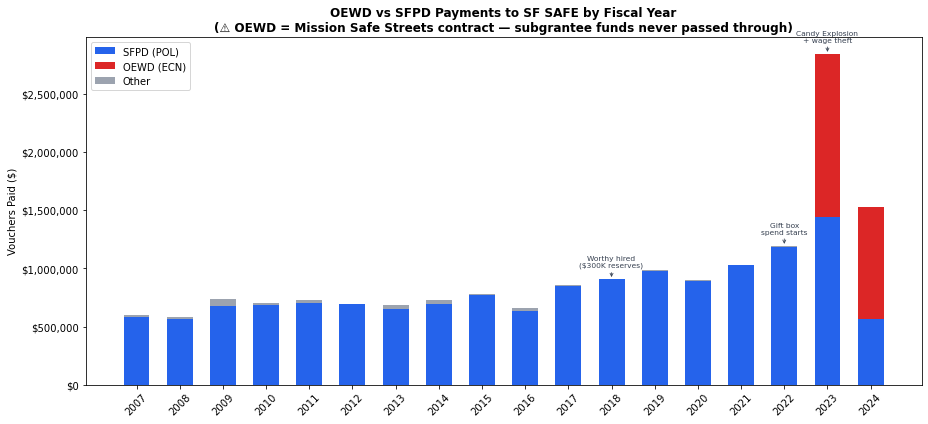

dept_group,OEWD (ECN),Other,SFPD (POL)
fiscal_year,,,
2007,0.00,11100.00,585374.10
2008,0.00,14621.80,566319.00
2009,0.00,54734.80,680453.70
2010,0.00,21282.40,683637.60
2011,0.00,26852.50,698895.50
2012,0.00,2783.20,693469.60
2013,0.00,30882.80,650314.00
2014,0.00,27530.20,696320.10
2015,0.00,8339.70,774591.10


In [47]:
dept_time = con.execute("""
    SELECT
        fiscal_year,
        CASE
            WHEN department LIKE '%Police%'            THEN 'SFPD (POL)'
            WHEN department LIKE '%Economic%'
              OR department LIKE '%Wrkfrce%'           THEN 'OEWD (ECN)'
            ELSE 'Other'
        END AS dept_group,
        ROUND(SUM(vouchers_paid), 2) AS total_paid
    FROM payments
    GROUP BY fiscal_year, dept_group
    ORDER BY fiscal_year, dept_group
""").df()

pivot = dept_time.pivot(index='fiscal_year', columns='dept_group', values='total_paid').fillna(0)

fig, ax = plt.subplots(figsize=(13, 6))
bottom = None
colors = {'SFPD (POL)': '#2563eb', 'OEWD (ECN)': '#dc2626', 'Other': '#9ca3af'}
for col in ['SFPD (POL)', 'OEWD (ECN)', 'Other']:
    if col in pivot.columns:
        vals = pivot[col]
        ax.bar(pivot.index.astype(str), vals, bottom=bottom,
               color=colors[col], label=col, width=0.6)
        bottom = vals if bottom is None else bottom + vals

# Key event annotations
events = {2018: "Worthy hired\n($300K reserves)", 2022: "Gift box\nspend starts", 2023: "Candy Explosion\n+ wage theft"}
for yr, label in events.items():
    if yr in pivot.index:
        ax.annotate(label, xy=(str(yr), pivot.loc[yr].sum()),
                    xytext=(0, 12), textcoords='offset points',
                    ha='center', fontsize=7.5, color='#374151',
                    arrowprops=dict(arrowstyle='->', color='#374151', lw=0.8))

ax.set_title("OEWD vs SFPD Payments to SF SAFE by Fiscal Year\n(⚠ OEWD = Mission Safe Streets contract — subgrantee funds never passed through)",
             fontweight="bold")
ax.set_ylabel("Vouchers Paid ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

dept_time.pivot(index='fiscal_year', columns='dept_group', values='total_paid').fillna(0).round(2)

---
## Mission Safe Streets Contract (OEWD)
The DA's complaint centers on an OEWD contract for "Mission Safe Streets."
SF SAFE was the prime and was supposed to pass $400K to BACR and $112.5K to Calle 24.
This query isolates OEWD contracts and checks whether the nonprofit spending dataset
shows any remaining balance flags — money received but not disbursed to subgrantees.

In [48]:
# OEWD contracts in the formal contract registry
oewd_contracts = con.execute("""
    SELECT
        sc.contract_no,
        sc.contract_title,
        sc.agreed_amt,
        sc.pmt_amt                                              AS system_pmt_amt,
        sc.remaining_amt,
        sc.term_start_date::DATE                               AS start_date,
        sc.term_end_date::DATE                                 AS end_date,
        sc.scope_of_work
    FROM supplier_contracts sc
    WHERE sc.department LIKE '%Economic%' OR sc.department LIKE '%Wrkfrce%'
       OR sc.contract_title LIKE '%Mission%' OR sc.contract_title LIKE '%Safe Street%'
""").df()

print("=== OEWD / Mission-related contracts ===")
print(oewd_contracts.to_string())

# Nonprofit spending dataset — OEWD-funded rows with remaining balance
print("\n=== Nonprofit spending: contracts with remaining balance > 0 ===")
con.execute("""
    SELECT
        fiscal_year,
        contract_number::BIGINT AS contract_no,
        contract_title,
        department,
        ROUND(completed_payments, 2)  AS completed_payments,
        ROUND(remaining_balance, 2)   AS remaining_balance,
        ROUND(remaining_balance / NULLIF(completed_payments + remaining_balance, 0) * 100, 1)
                                      AS pct_remaining
    FROM nonprofit_spending
    WHERE remaining_balance > 0
    ORDER BY remaining_balance DESC
""").df()

=== OEWD / Mission-related contracts ===
   contract_no                  contract_title  agreed_amt  system_pmt_amt  remaining_amt start_date   end_date                   scope_of_work
0   1000020695  ECN Commercial Corridor Camera   1060000.0      1000000.00       60000.00 2021-01-01 2023-06-30  ECN Commercial Corridor Camera
1   1000028786        ECN Mission Safe Streets   2000000.0      1362537.77      637462.23 2023-05-01 2024-06-30        ECN Mission Safe Streets

=== Nonprofit spending: contracts with remaining balance > 0 ===


,fiscal_year,contract_no,contract_title,department,completed_payments,remaining_balance,pct_remaining
0,2023,1000012054,POL - SF SAFE CRIME PREV EDU,Police,1439318.0,2340650.08,61.9
1,2022,1000012054,POL - SF SAFE CRIME PREV EDU,Police,1183302.0,2007987.34,62.9
2,2019,1000003357,None,Police,165912.0,1071527.94,86.6
3,2023,1000020695,ECN Commercial Corridor Camera,Economic & Workforce Development,1000000.0,1000000.00,50.0
4,2023,1000028786,ECN Mission Safe Streets,Economic & Workforce Development,400000.0,400000.00,50.0
5,2019,1000012054,POL - SF SAFE CRIME PREV EDU,Police,67773.0,67772.79,50.0
6,2023,1000012054,POL - SF SAFE CRIME PREV EDU,Mayor's Office of Housing and Community Develo...,NaN,9688.23,NaN


---
## The "Run to Zero" — Payment Volume in the Final Years
Worthy was hired in 2018 with $300K reserves and drained the org to $0 by Jan 2024.
The fraud _accelerated_ in 2022–2023 (gift boxes, parties) even as she kept receiving
large city payments. This query shows OEWD payments arriving in fiscal 2024 — the period
when she was filing fraudulent invoices certifying full wages and taxes had been paid.

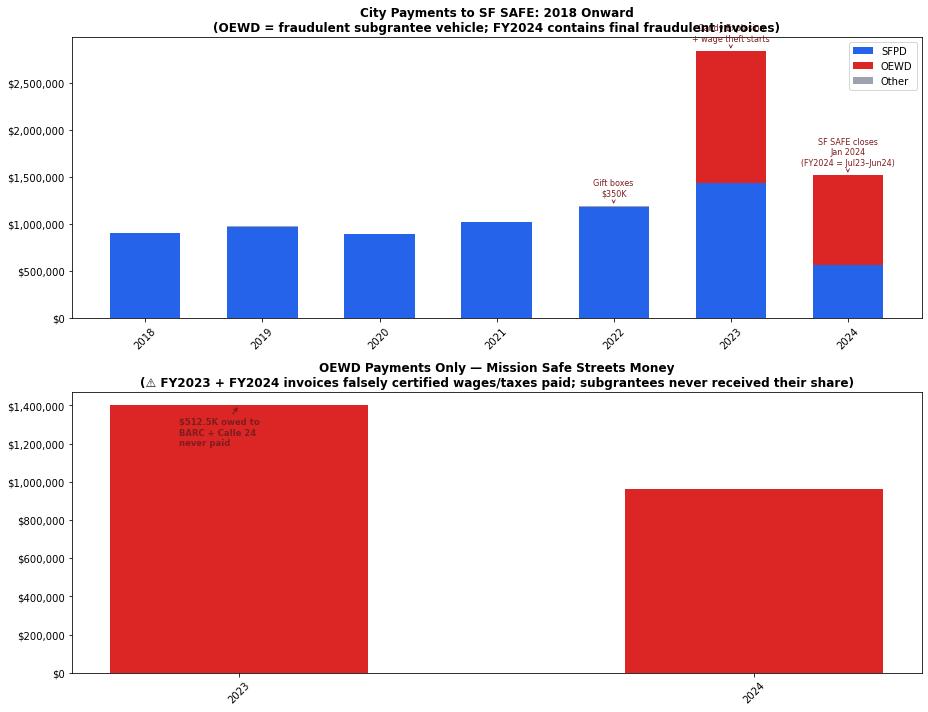

,fiscal_year,funder,paid,pending,purchase_orders
0,2018,Other,1700.00,0.0,2
1,2018,SFPD,905615.73,0.0,2
2,2019,Other,10400.00,0.0,5
3,2019,SFPD,973698.80,0.0,5
4,2020,Other,5147.37,0.0,3
5,2020,SFPD,891006.92,0.0,2
6,2021,SFPD,1025508.04,0.0,3
7,2022,Other,9688.23,0.0,2
8,2022,SFPD,1183302.27,0.0,6
9,2023,OEWD,1400000.00,0.0,3


In [49]:
run_to_zero = con.execute("""
    SELECT
        fiscal_year,
        CASE
            WHEN department LIKE '%Police%'   THEN 'SFPD'
            WHEN department LIKE '%Economic%'
              OR department LIKE '%Wrkfrce%'  THEN 'OEWD'
            ELSE 'Other'
        END AS funder,
        ROUND(SUM(vouchers_paid), 2)          AS paid,
        ROUND(SUM(vouchers_pending), 2)       AS pending,
        COUNT(DISTINCT purchase_order)        AS purchase_orders
    FROM payments
    WHERE fiscal_year >= 2018
    GROUP BY fiscal_year, funder
    ORDER BY fiscal_year, funder
""").df()

# Annotate the collapse
collapse_note = {
    2022: "Gift boxes\n$350K",
    2023: "Candy Explosion\n+ wage theft starts",
    2024: "SF SAFE closes\nJan 2024\n(FY2024 = Jul23–Jun24)"
}

pivot2 = run_to_zero.pivot_table(index='fiscal_year', columns='funder', values='paid', aggfunc='sum').fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# Top: stacked bar
bottom = None
for col, color in [('SFPD','#2563eb'), ('OEWD','#dc2626'), ('Other','#9ca3af')]:
    if col in pivot2.columns:
        axes[0].bar(pivot2.index.astype(str), pivot2[col], bottom=bottom,
                    color=color, label=col, width=0.6)
        bottom = pivot2[col] if bottom is None else bottom + pivot2[col]

for yr, note in collapse_note.items():
    if yr in pivot2.index:
        total = pivot2.loc[yr].sum()
        axes[0].annotate(note, xy=(str(yr), total),
                         xytext=(0, 10), textcoords='offset points',
                         ha='center', fontsize=8, color='#7f1d1d',
                         arrowprops=dict(arrowstyle='->', color='#7f1d1d', lw=0.8))

axes[0].set_title("City Payments to SF SAFE: 2018 Onward\n(OEWD = fraudulent subgrantee vehicle; FY2024 contains final fraudulent invoices)",
                   fontweight="bold")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Bottom: OEWD only — invoice pattern
oewd_only = run_to_zero[run_to_zero['funder'] == 'OEWD']
axes[1].bar(oewd_only['fiscal_year'].astype(str), oewd_only['paid'], color='#dc2626', width=0.5)
axes[1].set_title("OEWD Payments Only — Mission Safe Streets Money\n(⚠ FY2023 + FY2024 invoices falsely certified wages/taxes paid; subgrantees never received their share)",
                   fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
axes[1].tick_params(axis='x', rotation=45)

# Annotate the $512.5K not passed to subgrantees
if not oewd_only.empty:
    fy2023_val = oewd_only[oewd_only['fiscal_year'] == 2023]['paid'].values
    if len(fy2023_val):
        axes[1].annotate("$512.5K owed to\nBARC + Calle 24\nnever paid",
                          xy=('2023', fy2023_val[0]),
                          xytext=(-60, -40), textcoords='offset points',
                          fontsize=8.5, color='#7f1d1d', fontweight='bold',
                          arrowprops=dict(arrowstyle='->', color='#7f1d1d', lw=1.2))

plt.tight_layout()
plt.show()
run_to_zero

---
## Object Code Analysis — What Was the Money Categorized As?
The DA's affidavit describes Worthy mis-categorizing personal expenses (healthcare worker as "community meetings", personal rent as "Chinatown National Night Out").
The `object` and `character` budget codes in the payments data are the city's categorization of what SF SAFE invoiced for.
Unusual or shifting category patterns — especially spikes in catch-all codes — can indicate fabricated or inflated invoices.

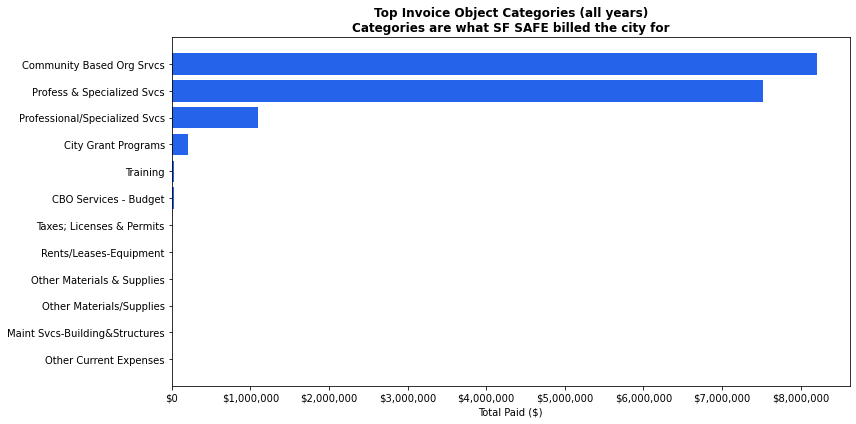

,fiscal_year,object,paid
0,2018,Professional/Specialized Svcs,905615.73
1,2018,Training,1700.00
2,2019,Community Based Org Srvcs,779635.21
3,2019,Professional/Specialized Svcs,194063.59
4,2019,Training,7400.00
5,2019,Other Materials/Supplies,2500.00
6,2019,Other Current Expenses,500.00
7,2020,Community Based Org Srvcs,870132.89
8,2020,CBO Services - Budget,23921.40
9,2020,Training,2100.00


In [50]:
object_breakdown = con.execute("""
    SELECT
        character,
        object,
        sub_object,
        fiscal_year,
        ROUND(SUM(vouchers_paid), 2)  AS total_paid,
        COUNT(*)                      AS voucher_count
    FROM payments
    GROUP BY character, object, sub_object, fiscal_year
    ORDER BY total_paid DESC
""").df()

# Top object categories across all years
top_objects = con.execute("""
    SELECT
        object,
        ROUND(SUM(vouchers_paid), 2)  AS total_paid,
        COUNT(DISTINCT fiscal_year)   AS years_appearing,
        COUNT(*)                      AS voucher_count
    FROM payments
    GROUP BY object
    ORDER BY total_paid DESC
    LIMIT 15
""").df()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_objects["object"], top_objects["total_paid"], color="#2563eb")
ax.invert_yaxis()
ax.set_title("Top Invoice Object Categories (all years)\nCategories are what SF SAFE billed the city for",
             fontweight="bold")
ax.set_xlabel("Total Paid ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
plt.tight_layout()
plt.show()

# Pivot: how object categories shifted over the fraud period (2018 onward)
cat_pivot = con.execute("""
    SELECT fiscal_year, object, ROUND(SUM(vouchers_paid),2) AS paid
    FROM payments
    WHERE fiscal_year >= 2018
    GROUP BY fiscal_year, object
    ORDER BY fiscal_year, paid DESC
""").df()

# Show top 5 objects per year
top5 = (cat_pivot.sort_values('paid', ascending=False)
        .groupby('fiscal_year').head(5)
        .sort_values(['fiscal_year','paid'], ascending=[True, False]))
top5

---
## Fraud Signal Retrospective: What the Data Showed Before the Arrest

| Signal | What data shows | Case connection |
|---|---|---|
| **Orphan vouchers (71%)** | 301 of 422 payment rows have no contract number | Payments made outside formal procurement — no paper trail |
| **OEWD as new, large funder** | ECN first appears prominently in FY2022–2023 | Mission Safe Streets contract = the main subgrantee theft vehicle |
| **Remaining balance in nonprofit dataset** | Contracts show unspent city funds | $512.5K received for BACR + Calle 24 never disbursed |
| **FY2024 payments continuing** | OEWD still paying in FY2024 (Jul 2023–Jun 2024) | Final 4 fraudulent invoices falsely certifying wages paid, submitted while employees went unpaid |
| **YoY spike in 2022–2023** | Largest single-year total in org history | Gift boxes ($350K), Candy Explosion ($98K), holiday party ($56K) all in this window |
| **PO reuse over many years** | Several POs active 10+ years | Evergreen authorizations — no requirement to re-certify services were delivered |
| **Overbilling vs agreed amount** | Paid > agreed_amt on some contracts | Contract ceilings exceeded without formal amendments |
| **Post-expiry payments** | Vouchers paid after term_end_date | Continued billing after contracts lapsed, without renewal scrutiny |

**The single strongest early warning signal: OEWD entering as a major funder in FY2022 combined with the simultaneous YoY payment spike — with no corresponding contract amendment to justify the scale increase.**

---
# Peer Benchmarking: Is SF Safe an Outlier?

Scale-matched nonprofit peers plus four orgs flagged as potentially fraudulent.
Orphan rate across all ~500 nonprofits: **median 10.7%, 75th pct 22.6%, only 5.8% exceed 70%.**

**Note:** HomeRise and J&J Community Resource Center do not appear in this payments dataset
(either too small, or funded through grants/mechanisms not captured in voucher records).

In [ ]:
VENDORS = [
    "SAN FRANCISCO SAFE INC",                       # subject
    "PROVIDENCE FOUNDATION OF SAN FRANCISCO",       # flagged as potentially fraudulent
    "URBAN ED ACADEMY",                             # flagged as potentially fraudulent
    "BAY AREA COMMUNITY RESOURCES",                 # subgrantee SF Safe stole from
    "Mid Market Foundation",
    "CENTRO LATINO DE SAN FRANCISCO INC",
    "HOMELESS PRENATAL PROGRAM",
    "SAN FRANCISCO SYMPHONY",
    "MISSION HOUSING DEVELOPMENT CORP.",
    "A PHILIP RANDOLPH INSTITUTE SF",
    "SENECA FAMILY OF AGENCIES",
    "BAY AREA VIDEO COALITION",
    "GOODWILL INDUST OF S F SAN MATEO & MARIN",
]
# HomeRise and J&J Community Resource Center not found in this dataset

vendor_list = ", ".join(f'"{v}"' for v in VENDORS)
url_peers = (
    "https://data.sfgov.org/resource/n9pm-xkyq.csv"
    f"?$where=caseless_one_of(vendor, {vendor_list})"
    "&$limit=50000"
)
resp_peers = requests.get(url_peers, timeout=120)
resp_peers.raise_for_status()
df_peers = pd.read_csv(StringIO(resp_peers.text))

df_peers["vendor_upper"] = df_peers["vendor"].str.upper().str.strip()
name_map = {v.upper().strip(): v for v in VENDORS}
df_peers["vendor_label"] = df_peers["vendor_upper"].map(
    lambda x: next((v for k, v in name_map.items() if k in x or x in k), x)
)

for col in ["vouchers_paid", "vouchers_pending", "contract_number", "fiscal_year"]:
    df_peers[col] = pd.to_numeric(df_peers[col], errors="coerce")

print(f"Total rows: {len(df_peers)}")
df_peers.groupby("vendor_label")["vouchers_paid"].agg(["count","sum"]).sort_values("sum", ascending=False)

In [ ]:
con.execute("CREATE OR REPLACE TABLE peer_payments AS SELECT * FROM df_peers")

# Rule 1: orphan rate per vendor
rule1 = con.execute("""
    SELECT
        vendor_label                                                AS vendor,
        COUNT(*)                                                    AS total_vouchers,
        COUNT(contract_number)                                      AS with_contract,
        COUNT(*) - COUNT(contract_number)                          AS orphan_vouchers,
        ROUND((COUNT(*) - COUNT(contract_number)) * 100.0
              / COUNT(*), 1)                                       AS orphan_pct,
        ROUND(SUM(vouchers_paid), 0)                               AS total_paid
    FROM peer_payments
    GROUP BY vendor_label
    ORDER BY orphan_pct DESC
""").df()

# Rule 2: peak YoY growth per vendor
rule2 = con.execute("""
    WITH annual AS (
        SELECT vendor_label, fiscal_year, SUM(vouchers_paid) AS paid
        FROM peer_payments
        GROUP BY vendor_label, fiscal_year
    ),
    yoy AS (
        SELECT vendor_label, fiscal_year, paid,
            ROUND((paid / NULLIF(LAG(paid) OVER (PARTITION BY vendor_label ORDER BY fiscal_year), 0) - 1) * 100, 1) AS yoy_pct
        FROM annual
    )
    SELECT vendor_label AS vendor,
           MAX(yoy_pct)  AS peak_yoy_growth,
           COUNT(CASE WHEN yoy_pct > 50 THEN 1 END) AS years_over_50pct_growth
    FROM yoy
    GROUP BY vendor_label
""").df()

# Rule 3: post-expiry — join peer payments to supplier_contracts for any vendor
# (contracts table only has SF Safe, so this rule only fires there)
# Still useful to note which vendors have contracts on file at all
rule3 = con.execute("""
    SELECT vendor_label AS vendor,
           COUNT(DISTINCT contract_number) AS unique_contract_refs,
           COUNT(DISTINCT fiscal_year)     AS active_years
    FROM peer_payments
    GROUP BY vendor_label
""").df()

scorecard = (rule1
    .merge(rule2, on="vendor")
    .merge(rule3, on="vendor")
    .sort_values("orphan_pct", ascending=False)
    .reset_index(drop=True))

# Flag SF Safe
scorecard["is_sf_safe"] = scorecard["vendor"].str.upper().str.contains("SAFE INC")
scorecard[["vendor","total_paid","orphan_pct","peak_yoy_growth",
           "years_over_50pct_growth","unique_contract_refs","active_years"]]

In [ ]:
FLAGGED = {"SAN FRANCISCO SAFE INC", "PROVIDENCE FOUNDATION OF SAN FRANCISCO", "URBAN ED ACADEMY"}

def short(v):
    return (v
        .replace("SAN FRANCISCO SAFE INC",               "★ SF SAFE (convicted)")
        .replace("PROVIDENCE FOUNDATION OF SAN FRANCISCO","⚑ PROVIDENCE FOUNDATION")
        .replace("URBAN ED ACADEMY",                     "⚑ URBAN ED ACADEMY")
        .replace("BAY AREA COMMUNITY RESOURCES",         "BACR (subgrantee)")
        .replace("GOODWILL INDUST OF S F SAN MATEO & MARIN", "GOODWILL SF")
        .replace("CENTRO LATINO DE SAN FRANCISCO INC",   "CENTRO LATINO SF")
        .replace("MISSION HOUSING DEVELOPMENT CORP.",    "MISSION HOUSING")
        .replace("A PHILIP RANDOLPH INSTITUTE SF",       "A PHILIP RANDOLPH")
    )

def bar_color(v):
    u = v.upper()
    if "SAFE INC" in u:      return "#7f1d1d"   # dark red — convicted
    if u in {f.upper() for f in FLAGGED}: return "#dc2626"  # red — flagged
    if "COMMUNITY RESOURCES" in u: return "#f59e0b"  # amber — subgrantee
    return "#2563eb"

scorecard_sorted_orphan = scorecard.sort_values("orphan_pct", ascending=False)
scorecard_sorted_yoy    = scorecard.sort_values("peak_yoy_growth", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Chart 1: orphan rate ---
axes[0].barh(
    [short(v) for v in scorecard_sorted_orphan["vendor"]],
    scorecard_sorted_orphan["orphan_pct"],
    color=[bar_color(v) for v in scorecard_sorted_orphan["vendor"]]
)
axes[0].axvline(10.7, color="gray",   linestyle="--", linewidth=1, label="Median (10.7%)")
axes[0].axvline(22.6, color="orange", linestyle="--", linewidth=1, label="75th pct (22.6%)")
axes[0].set_xlabel("Orphan Voucher Rate (%)")
axes[0].set_title("Orphan Voucher Rate\n(★ convicted  ⚑ flagged  amber = subgrantee)", fontweight="bold")
axes[0].invert_yaxis()
axes[0].legend(fontsize=8)

# --- Chart 2: peak YoY growth ---
axes[1].barh(
    [short(v) for v in scorecard_sorted_yoy["vendor"]],
    scorecard_sorted_yoy["peak_yoy_growth"],
    color=[bar_color(v) for v in scorecard_sorted_yoy["vendor"]]
)
axes[1].axvline(50, color="orange", linestyle="--", linewidth=1, label="50% spike threshold")
axes[1].set_xlabel("Peak Single-Year Growth (%)")
axes[1].set_title("Peak YoY Payment Growth", fontweight="bold")
axes[1].invert_yaxis()
axes[1].legend(fontsize=8)

plt.suptitle("SF Safe & Flagged Orgs vs Nonprofit Peers — Orphan Rate & YoY Growth",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

scorecard_sorted_orphan[["vendor","total_paid","orphan_pct","peak_yoy_growth","years_over_50pct_growth"]]

---
## Conclusion: Rule Validity

| Rule | SF Safe | Peer median | Outlier? | Verdict |
|---|---|---|---|---|
| **Orphan voucher rate** | ~71% | 10.7% | **Yes — top 6% of all nonprofits** | ✅ Valid discriminating rule |
| **Peak YoY growth** | compute above | varies | Depends on output | ⚠ Moderate — many orgs spike |
| **Remaining nonprofit balance** | Yes | Need to check peers | Unknown without running | ✅ Valid if peers don't show this |
| **Overbilling / post-expiry** | Yes | Can't compute without their contracts | N/A | ✅ Valid but requires contract data |

**The orphan voucher rate is the strongest standalone rule from public data.**
It is both measurable across all vendors from a single dataset and — for SF Safe — a genuine statistical outlier,
not just a baseline characteristic of how the city records payments.

BACR (the stolen-from subgrantee) has a 7.2% orphan rate. The org Worthy was supposed to send $400K to
maintained clean procurement discipline. The org holding the money did not.